In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymongo

In [2]:
df = pd.read_csv("data.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
data = df.to_dict(orient="records")
# data

In [4]:
DB_NAME = "Vehical_Insurance"
COLLECTION_NAME = "Vehical_Insurance_Data"
CONNECTION_URL = "mongodb://localhost:27017"

In [5]:
client = pymongo.MongoClient(CONNECTION_URL)
data_base = client[DB_NAME]
collection = data_base[COLLECTION_NAME]

In [6]:
# Uploading data to MongoDB
rec = collection.insert_many(data)

In [16]:
# for doc in collection.find():
#     print(doc)

In [7]:
# Load back data from mongodb

df = pd.DataFrame(list(collection.find()))
df.head()

,_id,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,69e668e1419d59e36f1a5f0d,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,69e668e1419d59e36f1a5f0e,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,69e668e1419d59e36f1a5f0f,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,69e668e1419d59e36f1a5f10,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,69e668e1419d59e36f1a5f11,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [8]:
df.shape

(762218, 13)

In [9]:
df.isnull().sum()

_id                     0
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762218 entries, 0 to 762217
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   _id                   762218 non-null  object 
 1   id                    762218 non-null  int64  
 2   Gender                762218 non-null  object 
 3   Age                   762218 non-null  int64  
 4   Driving_License       762218 non-null  int64  
 5   Region_Code           762218 non-null  float64
 6   Previously_Insured    762218 non-null  int64  
 7   Vehicle_Age           762218 non-null  object 
 8   Vehicle_Damage        762218 non-null  object 
 9   Annual_Premium        762218 non-null  float64
 10  Policy_Sales_Channel  762218 non-null  float64
 11  Vintage               762218 non-null  int64  
 12  Response              762218 non-null  int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 75.6+ MB


In [11]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,762218.000000,762218.000000,762218.000000,762218.000000,762218.000000,762218.000000,762218.000000,762218.000000,762218.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.764039,15.511601,0.046110,13.229879,0.498251,17213.143765,54.203959,83.671249,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


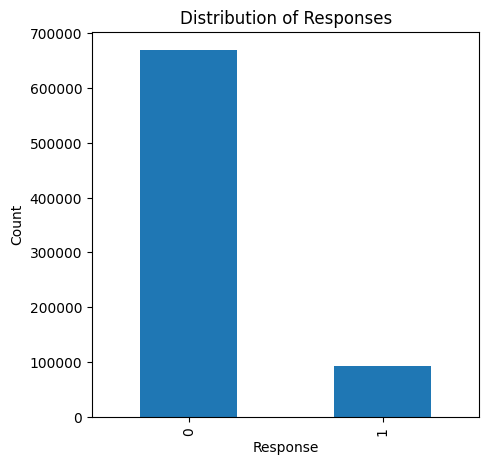

In [19]:
value_counts = df['Response'].value_counts()

plt.figure(figsize=(5, 5))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Responses')

# Show the plot
plt.show()

<Axes: >

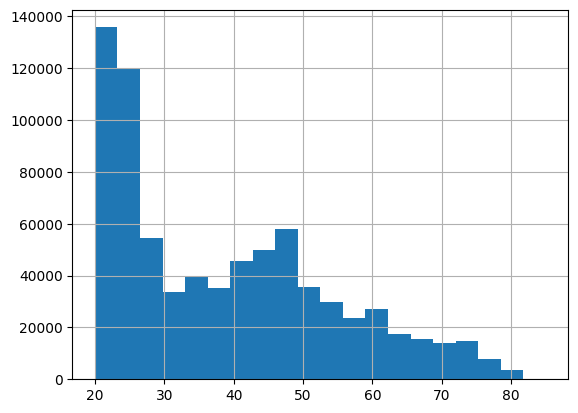

In [21]:
df['Age'].hist(bins=20)

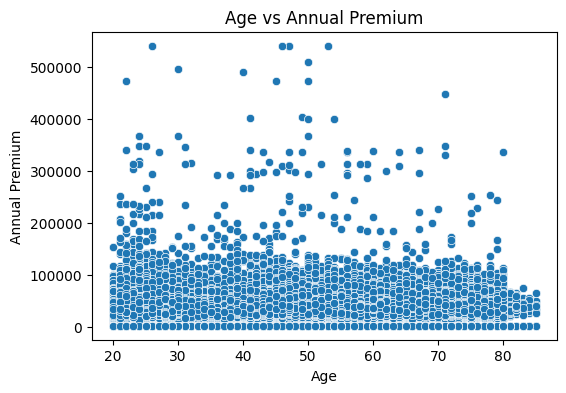

In [23]:
# Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='Annual_Premium', data=df)
plt.title('Age vs Annual Premium')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.show()